##Importing Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [2]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=True)

Mounted at /content/drive/


In [3]:
file_path_1 = '/content/drive/My Drive/Colab Notebooks/client_data.csv'
file_path_2 = '/content/drive/My Drive/Colab Notebooks/price_data.csv'

df_client = pd.read_csv(file_path_1)
df_price = pd.read_csv(file_path_2)

##Verifying Data

In [4]:
print(df_client.describe())

           cons_12m  cons_gas_12m  cons_last_month  forecast_cons_12m  \
count  1.460600e+04  1.460600e+04     14606.000000       14606.000000   
mean   1.592203e+05  2.809238e+04     16090.269752        1868.614880   
std    5.734653e+05  1.629731e+05     64364.196422        2387.571531   
min    0.000000e+00  0.000000e+00         0.000000           0.000000   
25%    5.674750e+03  0.000000e+00         0.000000         494.995000   
50%    1.411550e+04  0.000000e+00       792.500000        1112.875000   
75%    4.076375e+04  0.000000e+00      3383.000000        2401.790000   
max    6.207104e+06  4.154590e+06    771203.000000       82902.830000   

       forecast_cons_year  forecast_discount_energy  forecast_meter_rent_12m  \
count        14606.000000              14606.000000             14606.000000   
mean          1399.762906                  0.966726                63.086871   
std           3247.786255                  5.108289                66.165783   
min              0.000

In [5]:
print(df_price.describe())

       price_off_peak_var  price_peak_var  price_mid_peak_var  \
count       193002.000000   193002.000000       193002.000000   
mean             0.141027        0.054630            0.030496   
std              0.025032        0.049924            0.036298   
min              0.000000        0.000000            0.000000   
25%              0.125976        0.000000            0.000000   
50%              0.146033        0.085483            0.000000   
75%              0.151635        0.101673            0.072558   
max              0.280700        0.229788            0.114102   

       price_off_peak_fix  price_peak_fix  price_mid_peak_fix  
count       193002.000000   193002.000000       193002.000000  
mean            43.334477       10.622875            6.409984  
std              5.410297       12.841895            7.773592  
min              0.000000        0.000000            0.000000  
25%             40.728885        0.000000            0.000000  
50%             44.266930     

In [6]:
print(df_client.shape)

(14606, 26)


In [7]:
print(df_price.shape)

(193002, 8)


In [8]:
print(df_client.columns)

Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn'],
      dtype='object')


In [9]:
print(df_price.columns)

Index(['id', 'price_date', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix'],
      dtype='object')


##Data Visulization

In [10]:
def plot_stack_bar (dataframe,title_,size_ = (8,6),rot_ = 0,legend_ = 'upper left'):
  ax = dataframe.plot(kind='bar',stacked=True,figsize=size_,rot=rot_)
  ax.set_title(title_)
  ax.legend(loc=legend_)

  annotate_stack_bar(ax,textsize = 10)
  plt.legend(['Retention','Churn'],loc = legend_)
  plt.ylabel('Company base%')
  plt.show()


In [11]:
def annotate_stack_bar(ax,pad = 0.99,colour = 'White',textsize = 10):
  for p in ax.patches:
    value = str(round(p.get_height(),1))
    if value =='0.0':
      continue
    ax.annotate(
        value,
        ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
    )

##Exploring about churning rate

In [12]:
churn = df_client[['id','churn']]
churn.columns = ['Companies','churn']
churn_total = churn.groupby('churn').count()
churn_percentage = churn_total/churn_total.sum()*100
print(churn_percentage)

       Companies
churn           
0      90.284814
1       9.715186


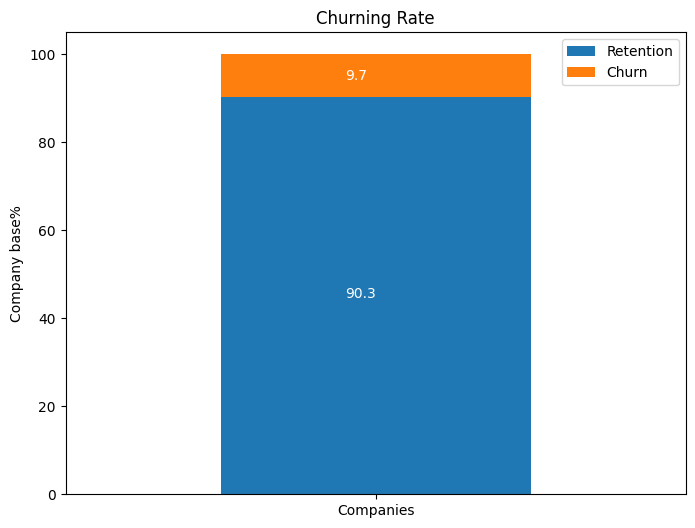

In [13]:
plot_stack_bar(churn_percentage.transpose(),'Churning Rate',(8,6),legend_='upper right')

In [14]:
channel = df_client[['id','channel_sales','churn']]
channel = channel.groupby([channel['channel_sales'], channel['churn']])['id'].count().unstack(level=1).fillna(0)
channel_churn = (channel.div(channel.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)

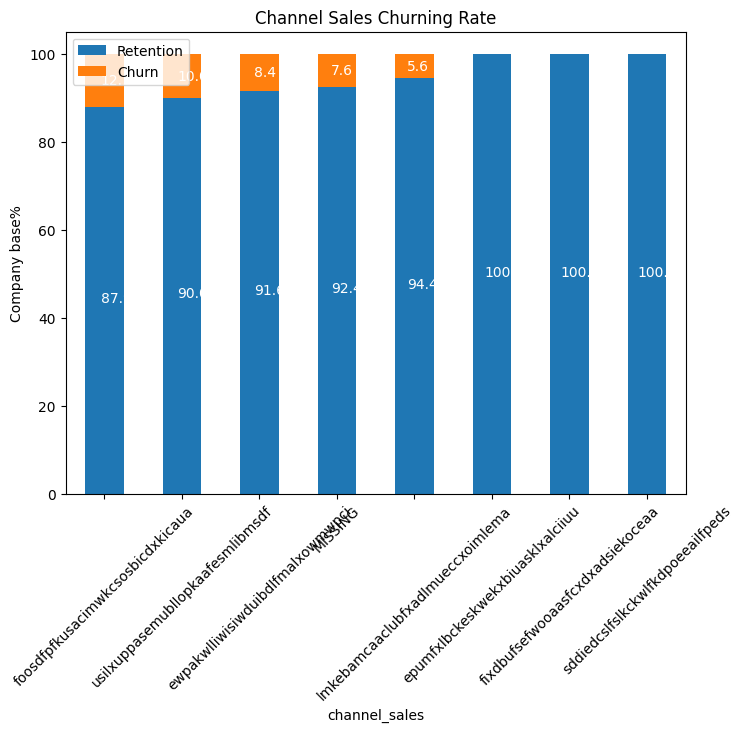

In [15]:
plot_stack_bar(channel_churn,'Channel Sales Churning Rate',rot_= 45)

##Consumption visualization

In [16]:
consumption = df_client[['id','cons_12m','cons_gas_12m','cons_last_month','imp_cons',
                         'has_gas','churn']]

In [17]:
def distribution_plot(dataframe, column, ax, bins_=30):
    temp = pd.DataFrame({
        "Retention": dataframe[dataframe['churn'] == 0][column],
        "Churn": dataframe[dataframe['churn'] == 1][column]
    })

    temp.plot(kind='hist', bins=bins_, ax=ax, stacked=True)

    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of {column}")

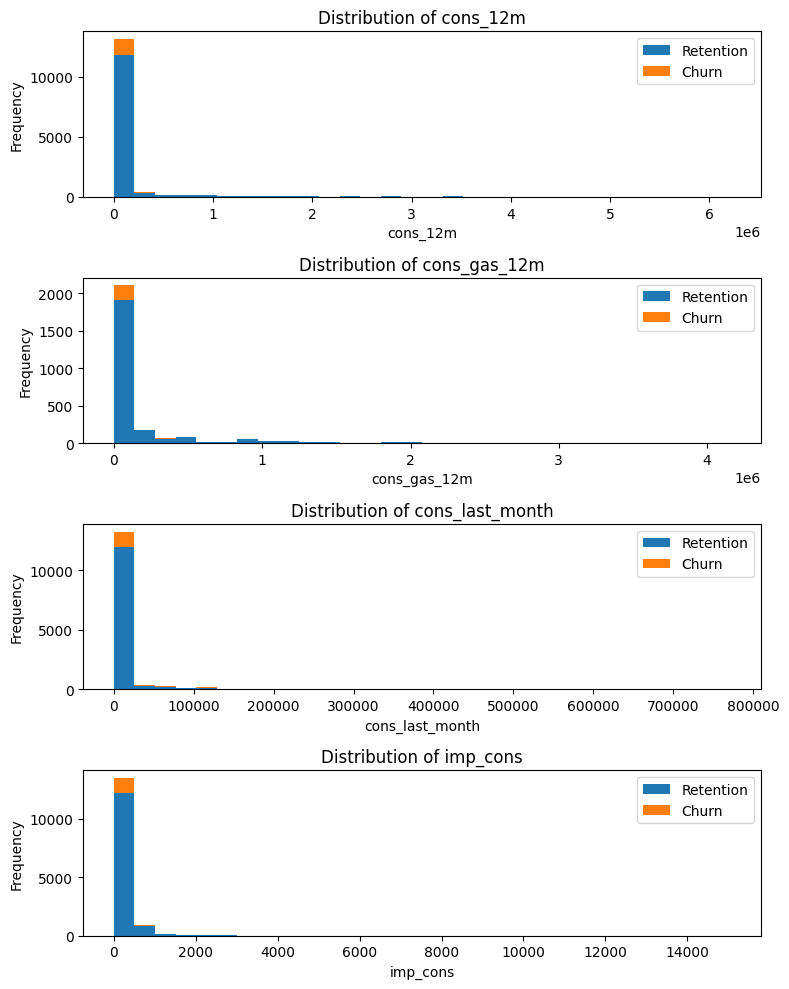

In [18]:
fig,axs = plt.subplots(nrows = 4,figsize = (8,10))
distribution_plot(consumption, 'cons_12m', axs[0])
distribution_plot(consumption[consumption['has_gas'] == 't'], 'cons_gas_12m', axs[1])
distribution_plot(consumption, 'cons_last_month', axs[2])
distribution_plot(consumption, 'imp_cons', axs[3])
plt.tight_layout()
plt.show()


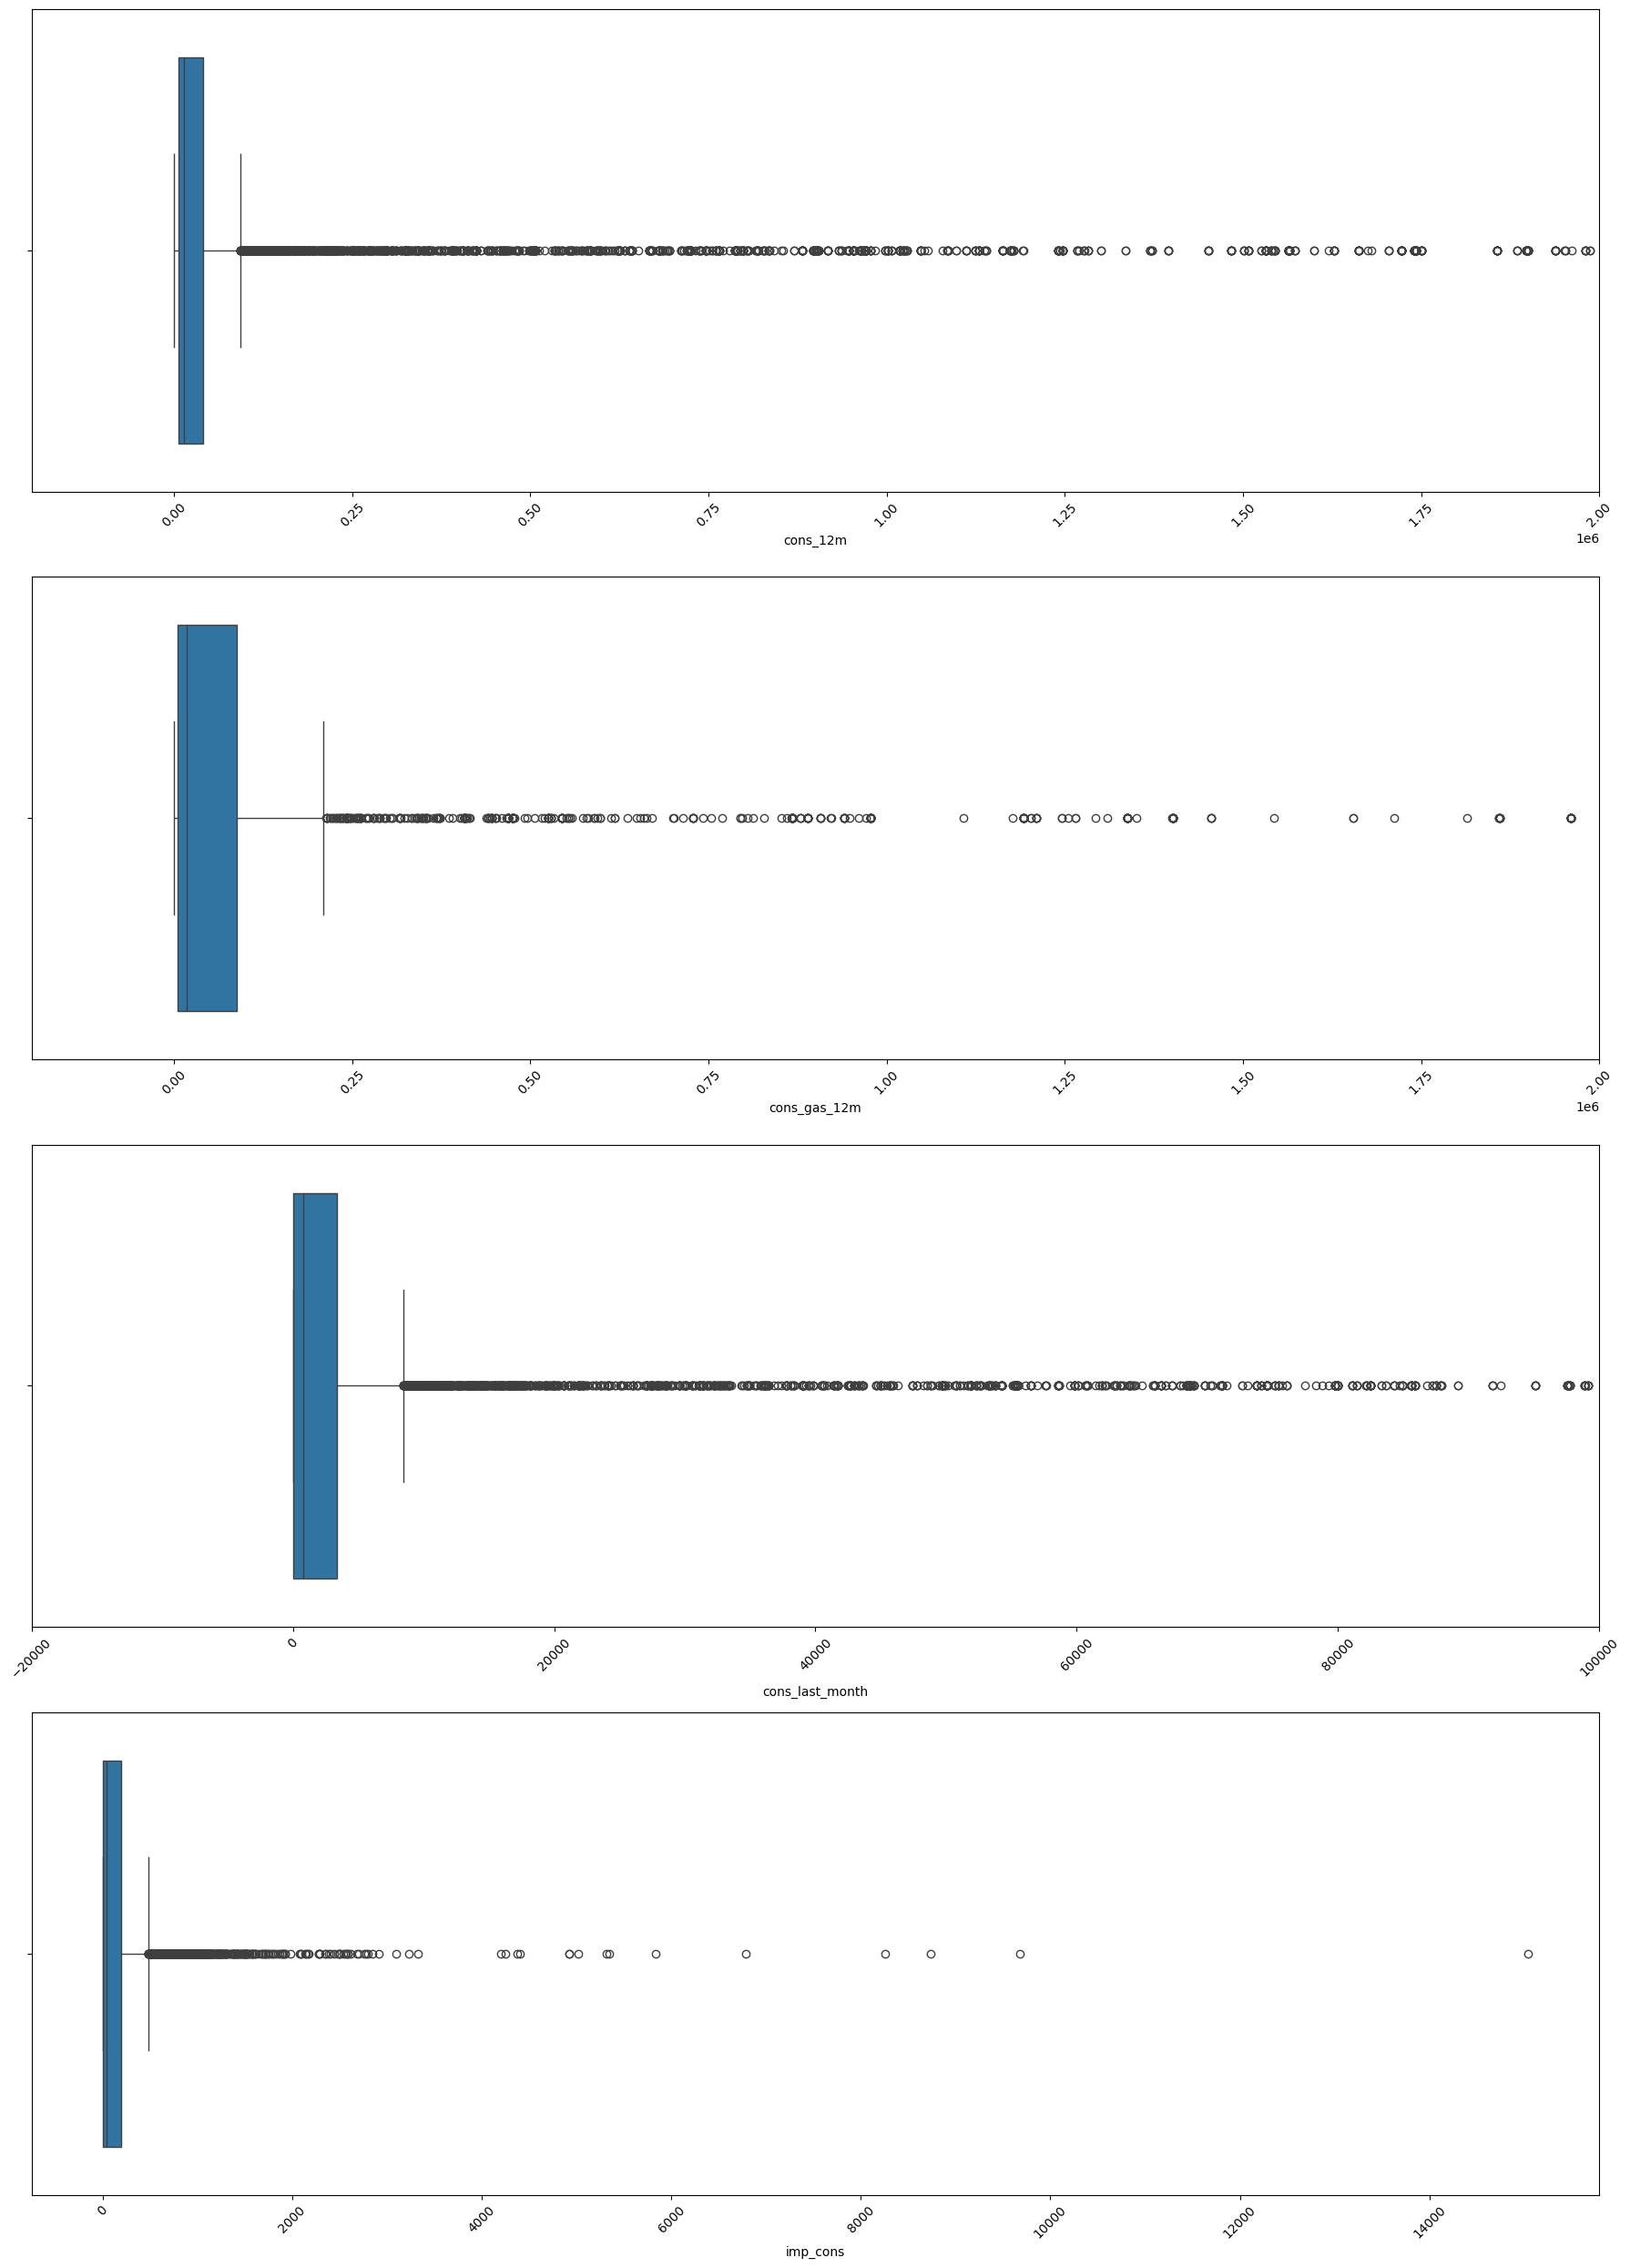

In [19]:
fig, axs = plt.subplots(nrows=4, figsize=(18, 25))

# Plot boxplots (switched x and y since boxplot usually has categories on y-axis)
sns.boxplot(x=consumption["cons_12m"], ax=axs[0])
sns.boxplot(x=consumption[consumption["has_gas"] == "t"]["cons_gas_12m"], ax=axs[1])
sns.boxplot(x=consumption["cons_last_month"], ax=axs[2])
sns.boxplot(x=consumption["imp_cons"], ax=axs[3])

# Remove scientific notation on x-axis
for ax in axs:
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=45)

# Set x-axis limits
axs[0].set_xlim(-200000, 2000000)
axs[1].set_xlim(-200000, 2000000)
axs[2].set_xlim(-20000, 100000)

# Adjust layout for better spacing
plt.tight_layout()

# Show plot
plt.show()

Forecasting Data

In [20]:
forecast = df_client[
    ["id", "forecast_cons_12m",
    "forecast_cons_year","forecast_discount_energy","forecast_meter_rent_12m",
    "forecast_price_energy_off_peak","forecast_price_energy_peak",
    "forecast_price_pow_off_peak","churn"
    ]
]

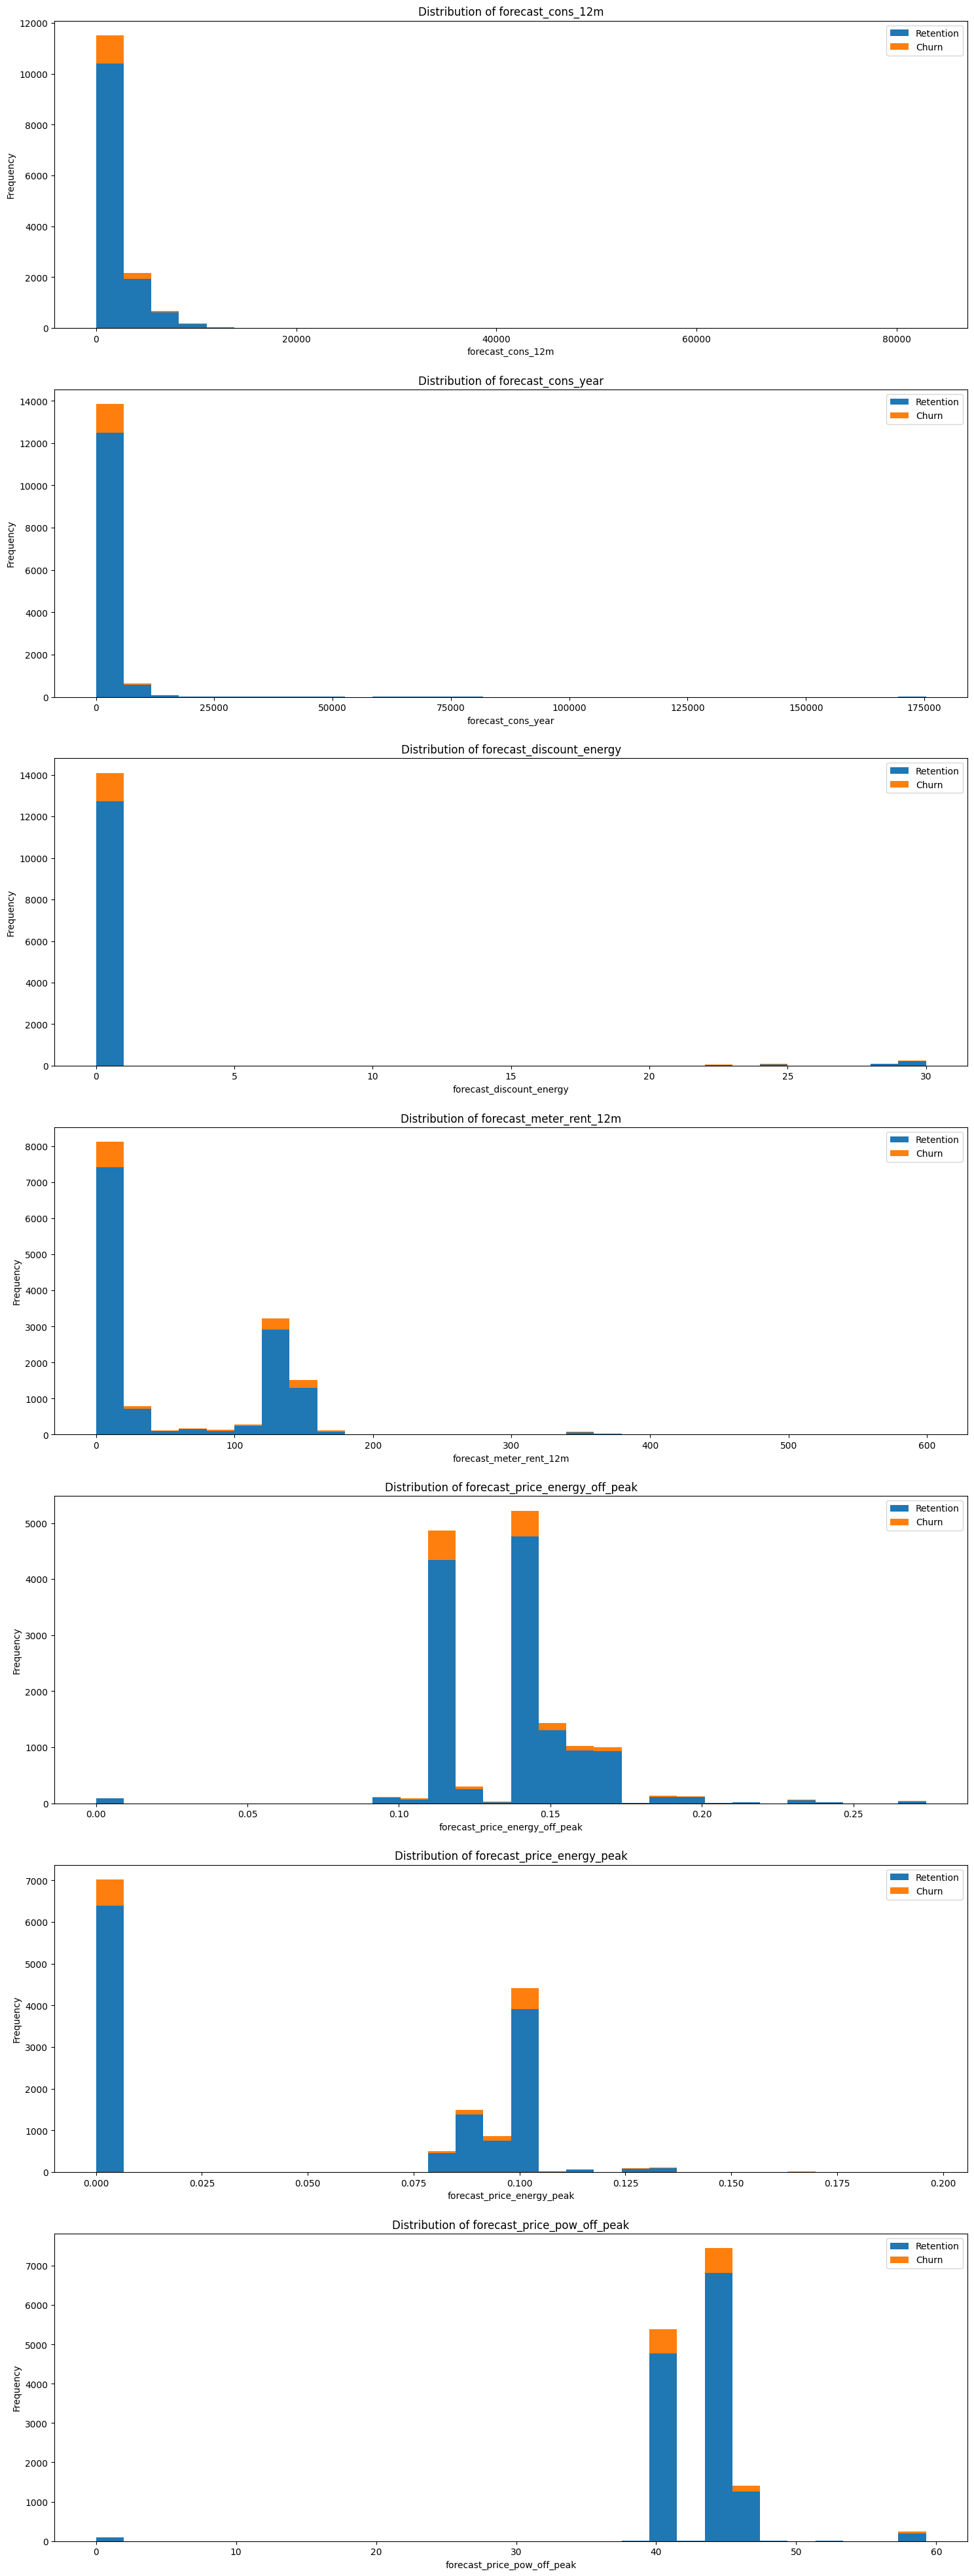

In [21]:
fig, axs = plt.subplots(nrows=7, figsize=(18,50))

# Plot histogram
distribution_plot(df_client, "forecast_cons_12m", axs[0])
distribution_plot(df_client, "forecast_cons_year", axs[1])
distribution_plot(df_client, "forecast_discount_energy", axs[2])
distribution_plot(df_client, "forecast_meter_rent_12m", axs[3])
distribution_plot(df_client, "forecast_price_energy_off_peak", axs[4])
distribution_plot(df_client, "forecast_price_energy_peak", axs[5])
distribution_plot(df_client, "forecast_price_pow_off_peak", axs[6])

##Contract type Analysis

In [22]:
contract_type = df_client[['id', 'has_gas', 'churn']]
contract = contract_type.groupby([contract_type['churn'], contract_type['has_gas']])['id'].count().unstack(level=0)
contract_percentage = (contract.div(contract.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)

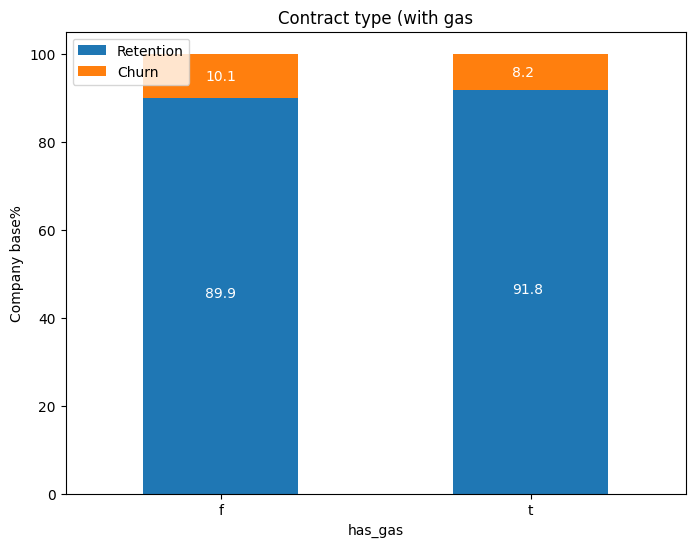

In [23]:
plot_stack_bar(contract_percentage, 'Contract type (with gas')

##Margin Analysis

In [24]:
margin = df_client[['id', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin']]

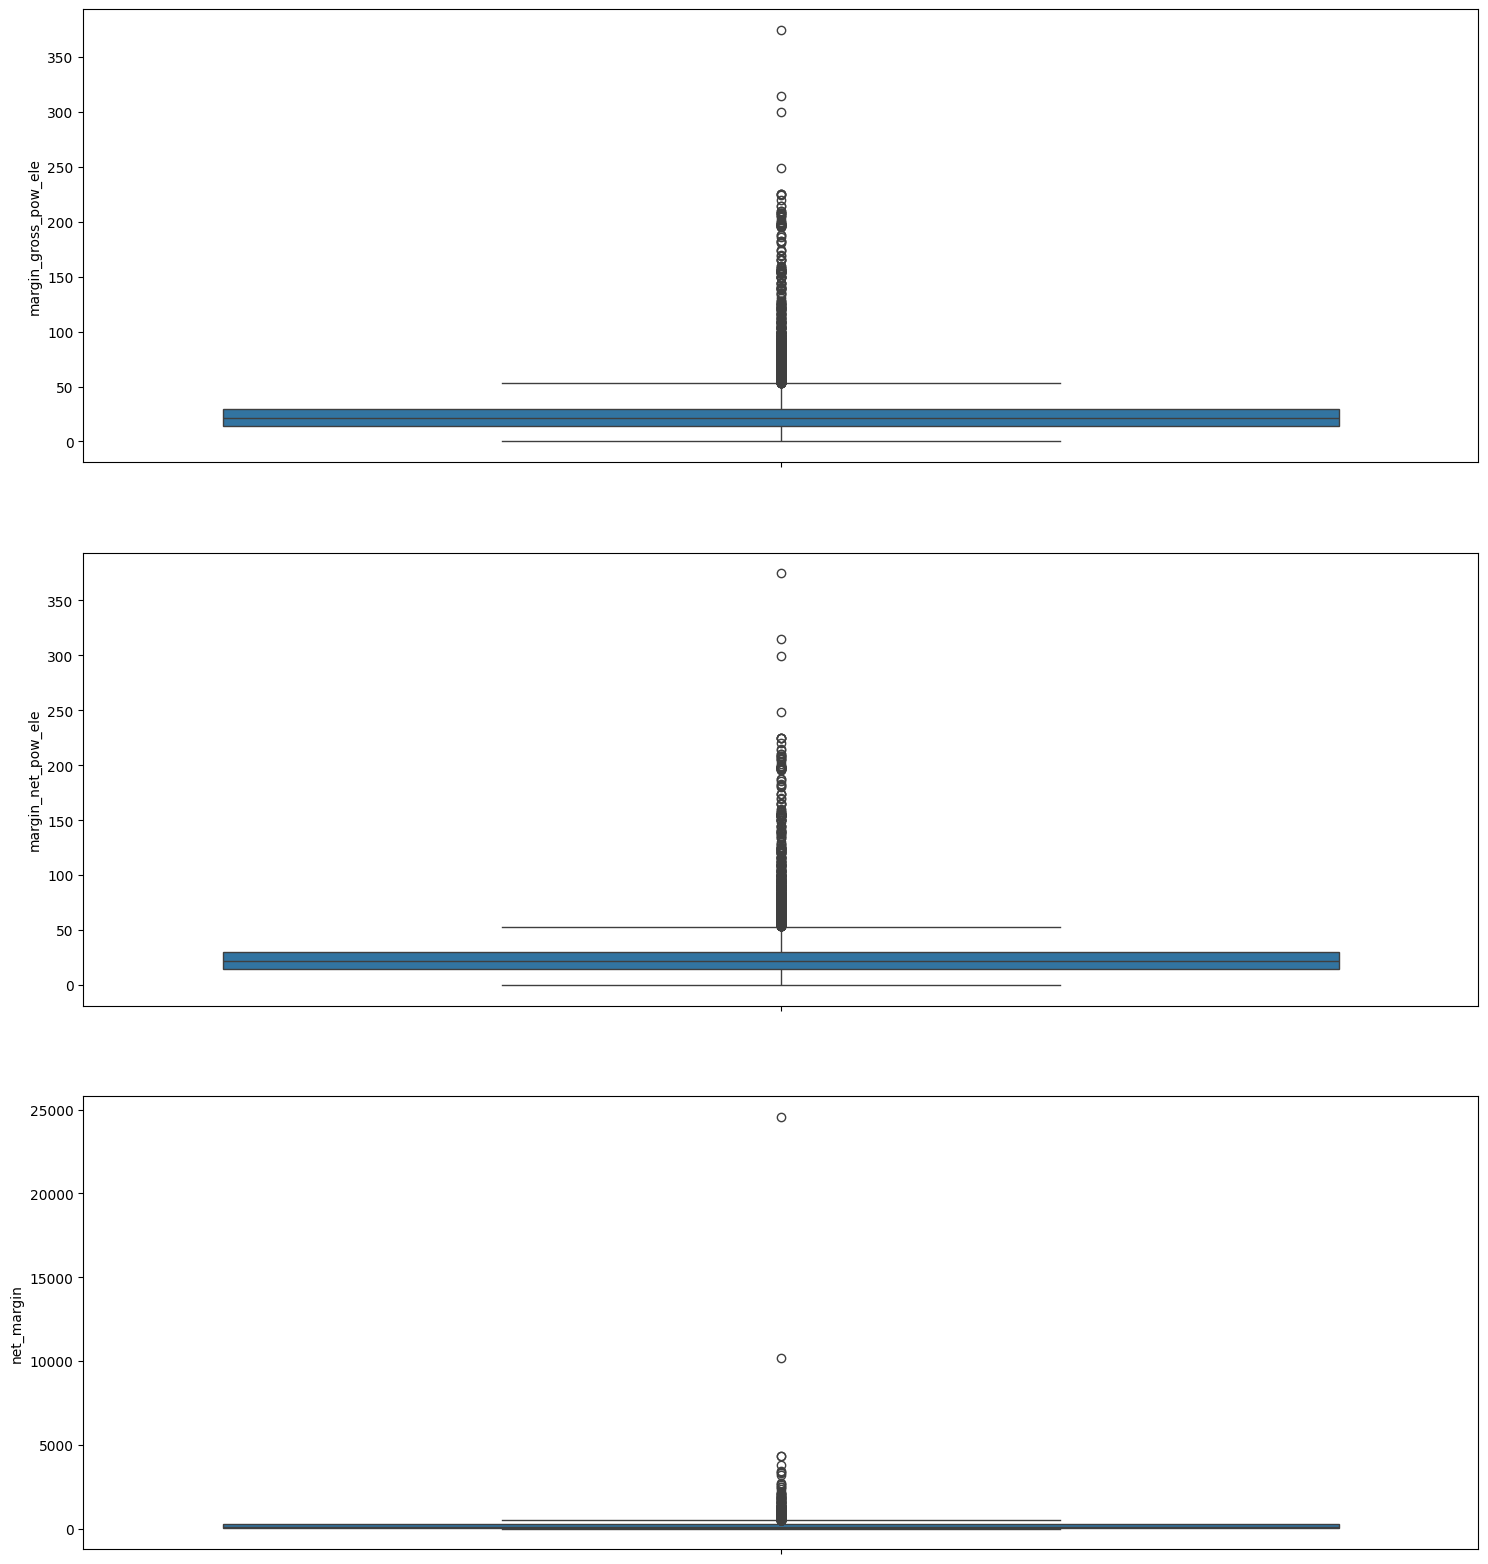

In [32]:
fig, axs = plt.subplots(nrows=3, figsize=(18,20))
# Plot histogram
sns.boxplot(margin["margin_gross_pow_ele"], ax=axs[0])
sns.boxplot(margin["margin_net_pow_ele"],ax=axs[1])
sns.boxplot(margin["net_margin"], ax=axs[2])
# Remove scientific notation
axs[0].ticklabel_format(style='plain', axis='y')
axs[1].ticklabel_format(style='plain', axis='y')
axs[2].ticklabel_format(style='plain', axis='y')
plt.show()

##Subscribed Power Analysis

In [26]:
power = df_client[['id', 'pow_max', 'churn']]

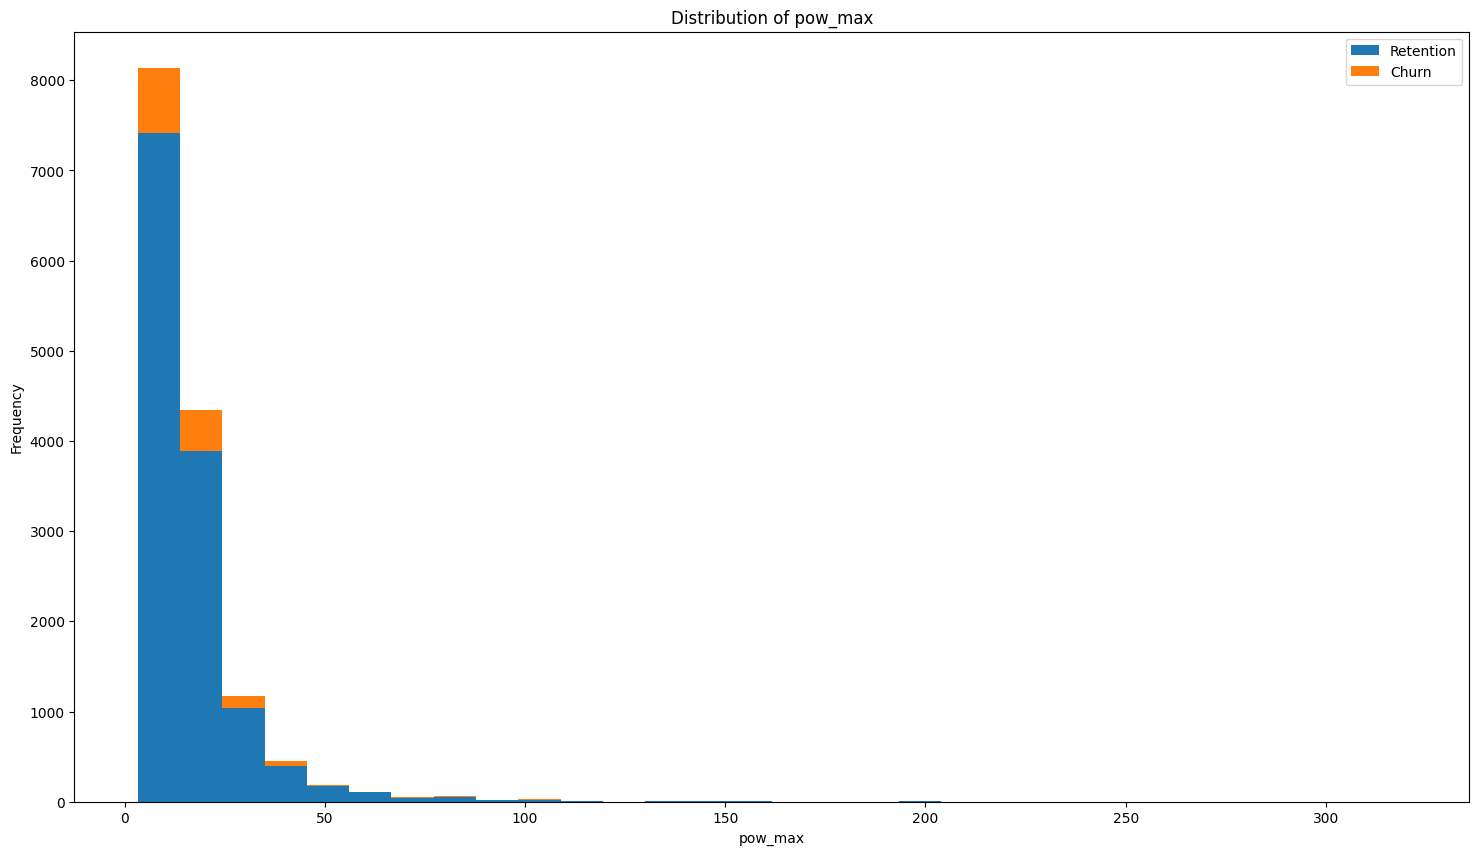

In [27]:
fig, axs = plt.subplots(nrows=1, figsize=(18, 10))
distribution_plot(power, 'pow_max', axs)

##Other columns

In [28]:
others = df_client[['id', 'nb_prod_act', 'num_years_antig', 'origin_up', 'churn']]
products = others.groupby([others["nb_prod_act"],others["churn"]])["id"].count().unstack(level=1)
products_percentage = (products.div(products.sum(axis=1), axis=0)*100).sort_values(by=[1], ascending=False)

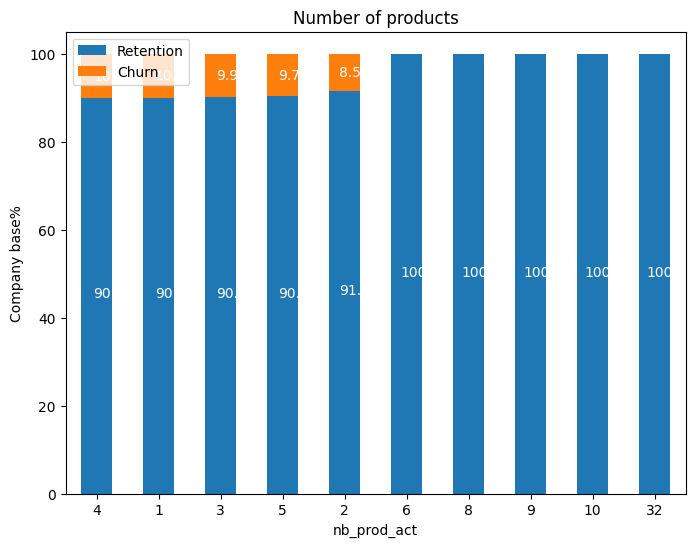

In [29]:
plot_stack_bar(products_percentage, "Number of products")

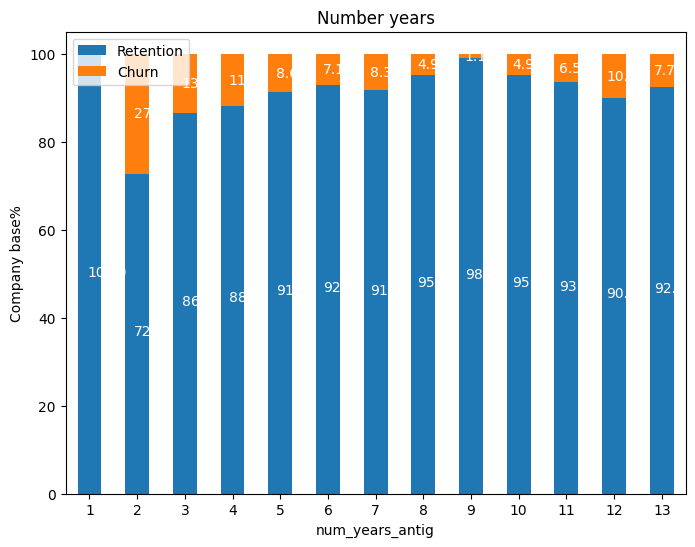

In [30]:
years_antig = others.groupby([others["num_years_antig"],others["churn"]])["id"].count().unstack(level=1)
years_antig_percentage = (years_antig.div(years_antig.sum(axis=1), axis=0)*100)
plot_stack_bar(years_antig_percentage, "Number years")

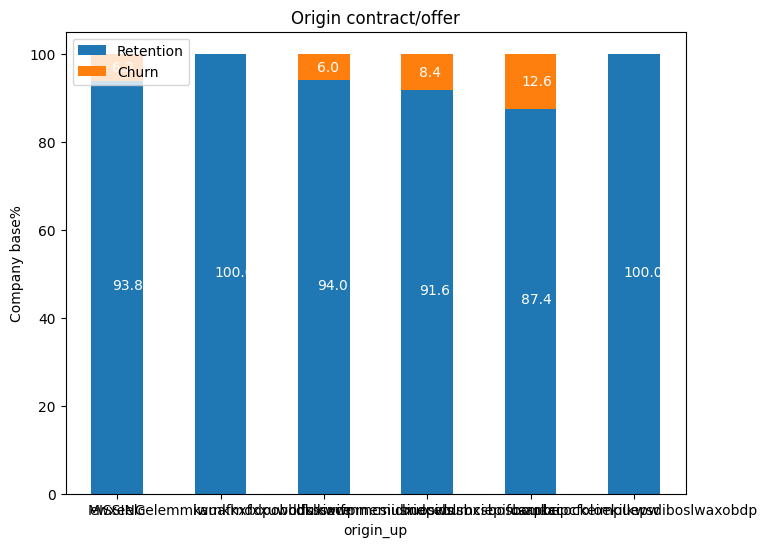

In [31]:
origin = others.groupby([others["origin_up"],others["churn"]])["id"].count().unstack(level=1)
origin_percentage = (origin.div(origin.sum(axis=1), axis=0)*100)
plot_stack_bar(origin_percentage, "Origin contract/offer")